# Stage 6: HDR & RAD Aggregation

Computes Hidden Dissatisfaction Rate (HDR) and Rating-Aspect Discrepancy (RAD) per category-aspect from the Stage 5 ABSA results.

**Inputs**: `s3://evahu-beyond-stars-raw/processed/absa/absa_results.parquet` (750K rows = 150K reviews × 5 aspects)

**Outputs**:
- `hdr_by_category_aspect.csv` — headline HDR table
- `hdr_by_year.csv` — time series breakdown
- `rad_by_category_aspect.csv` — rating-vs-aspect-sentiment discrepancy
- Plots inline below

**Method note**: Pandas (not Spark). Post-sampling data is 50MB; single-machine aggregation is the right tool. Stage 2 already demonstrated EMR Spark on the full 71M-row corpus.

## Setup

In [1]:
import os
import boto3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

BUCKET = 'evahu-beyond-stars-raw'
LOCAL = './data'
os.makedirs(LOCAL, exist_ok=True)

## Download ABSA results from S3

In [2]:
src = 'processed/absa/absa_results.parquet'
dst = os.path.join(LOCAL, 'absa_results.parquet')

if not os.path.exists(dst):
    s3 = boto3.client('s3')
    s3.download_file(BUCKET, src, dst)
    print(f'Downloaded {src} -> {dst}')
else:
    print(f'Using cached {dst}')

df = pd.read_parquet(dst)
print(f'Shape: {df.shape}')
df.head()

Downloaded processed/absa/absa_results.parquet -> ./data/absa_results.parquet
Shape: (750000, 7)


,review_id,category,rating,year,aspect,label,score
0,B001KKQ6UW_AE4AF7BJ3BXZRTJN2AXHMYCUCDEQ_161659...,Beauty_and_Personal_Care,5.0,2021,quality,Positive,0.584040
1,B008KEJ1LM_AGQAEIXHC3SFVXUHTYAEECVN6W5A_151444...,Beauty_and_Personal_Care,5.0,2017,quality,Positive,0.793527
2,B00ROSVV7M_AGZXF22DKOV4YRWSI6FEEURUBKGA_167959...,Beauty_and_Personal_Care,1.0,2023,quality,Negative,0.984439
3,B01BERO058_AGWVA2DEDR33XZQT4N6B6F2RYWHQ_147814...,Beauty_and_Personal_Care,4.0,2016,quality,Positive,0.987004
4,B00639DKCC_AFVRHRRG2HOLHMBEZZNW3E3DFU2Q_159771...,Beauty_and_Personal_Care,3.0,2020,quality,Positive,0.419935


In [3]:
print(df.dtypes)
print()
print('Categories:', df['category'].unique())
print('Aspects:', df['aspect'].unique())
print('Labels:', df['label'].unique())
print()
print('Rating distribution:')
print(df.drop_duplicates('review_id')['rating'].value_counts().sort_index())
print()
print('Year range:', df['year'].min(), '-', df['year'].max())

review_id     object
category      object
rating       float64
year           int64
aspect        object
label         object
score        float64
dtype: object

Categories: ['Beauty_and_Personal_Care' 'Video_Games' 'Electronics']
Aspects: ['quality' 'value' 'shipping' 'durability' 'usability']
Labels: ['Positive' 'Negative' 'Neutral']

Rating distribution:
rating
1.0    30089
2.0    30003
3.0    29863
4.0    29943
5.0    30076
Name: count, dtype: int64

Year range: 1999 - 2023


## Sanity check: label distribution per aspect

If most reviews are `Neutral` on most aspects, that's expected — most reviews don't discuss every aspect. The interesting signal is in the `Negative` rate among high-rating reviews.

In [4]:
label_dist = (df.groupby(['category', 'aspect', 'label'])
                .size()
                .unstack('label', fill_value=0))
label_dist['total'] = label_dist.sum(axis=1)
for col in ['Negative', 'Neutral', 'Positive']:
    label_dist[f'{col}_pct'] = label_dist[col] / label_dist['total'] * 100
label_dist[['Negative', 'Neutral', 'Positive', 'Negative_pct', 'Positive_pct']].round(2)

label                                Negative  Neutral  Positive  Negative_pct  Positive_pct
category                 aspect                                                             
Beauty_and_Personal_Care durability     27622      557     21821         55.24         43.64
                         quality        28442      608     20950         56.88         41.90
                         shipping       27856     2132     20012         55.71         40.02
                         usability      27031      932     22037         54.06         44.07
                         value          24227     1372     24401         48.45         48.80
Electronics              durability     27988      702     21310         55.98         42.62
                         quality        27805      806     21389         55.61         42.78
                         shipping       27830     2103     20067         55.66         40.13
                         usability      27765      908     21327         55.53         42.65
                         value          24363     1327     24310         48.73         48.62
Video_Games              durability     27870     1081     21049         55.74         42.10
                         quality        27690      945     21365         55.38         42.73
                         shipping       27343     2573     20084         54.69         40.17
                         usability      28028     1103     20869         56.06         41.74
                         value          24353     1576     24071         48.71         48.14

## HDR: Hidden Dissatisfaction Rate

Definition: among reviews with rating ≥ 4 stars, the fraction expressing **negative** sentiment toward a specific aspect.

$$\text{HDR}_{c,a} = \frac{|\{r : \text{rating}_r \geq 4 \land \text{sentiment}_{r,a} = \text{Negative}\}|}{|\{r : \text{rating}_r \geq 4\}|}$$

A high HDR on aspect $a$ in category $c$ means: many seemingly-satisfied customers (4-5 stars) are silently complaining about $a$. This is the "hidden" signal that star ratings miss.

In [5]:
high = df[df['rating'] >= 4].copy()
high['is_negative'] = (high['label'] == 'Negative').astype(int)

hdr = (high.groupby(['category', 'aspect'])
           .agg(n_high_rating=('review_id', 'count'),
                n_negative=('is_negative', 'sum'))
           .reset_index())
hdr['hdr'] = hdr['n_negative'] / hdr['n_high_rating']
hdr = hdr.sort_values(['category', 'hdr'], ascending=[True, False])
hdr

,category,aspect,n_high_rating,n_negative,hdr
1,Beauty_and_Personal_Care,quality,20083,3284,0.163521
2,Beauty_and_Personal_Care,shipping,20083,3110,0.154857
0,Beauty_and_Personal_Care,durability,20083,2918,0.145297
3,Beauty_and_Personal_Care,usability,20083,2746,0.136733
4,Beauty_and_Personal_Care,value,20083,1983,0.098740
6,Electronics,quality,19945,3206,0.160742
7,Electronics,shipping,19945,3089,0.154876
5,Electronics,durability,19945,3069,0.153873
8,Electronics,usability,19945,3012,0.151015
9,Electronics,value,19945,2089,0.104738


In [6]:
hdr.to_csv(os.path.join(LOCAL, 'hdr_by_category_aspect.csv'), index=False)
print('Saved hdr_by_category_aspect.csv')

Saved hdr_by_category_aspect.csv


### HDR visualization: heatmap

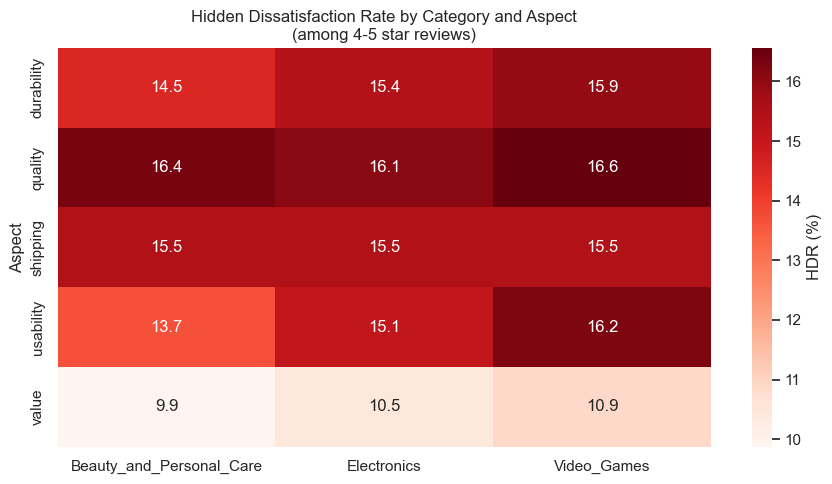

In [7]:
hdr_matrix = hdr.pivot(index='aspect', columns='category', values='hdr')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(hdr_matrix * 100, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'HDR (%)'}, ax=ax)
ax.set_title('Hidden Dissatisfaction Rate by Category and Aspect\n(among 4-5 star reviews)')
ax.set_xlabel('')
ax.set_ylabel('Aspect')
plt.tight_layout()
plt.savefig(os.path.join(LOCAL, 'hdr_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### HDR by category, grouped bars

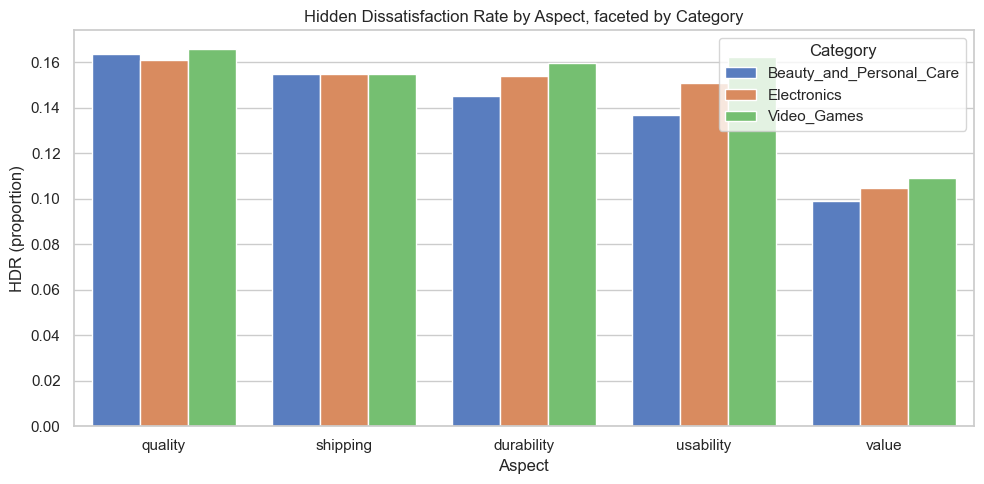

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=hdr, x='aspect', y='hdr', hue='category', ax=ax)
ax.set_ylabel('HDR (proportion)')
ax.set_xlabel('Aspect')
ax.set_title('Hidden Dissatisfaction Rate by Aspect, faceted by Category')
ax.legend(title='Category', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(LOCAL, 'hdr_bars.png'), dpi=150, bbox_inches='tight')
plt.show()

## RAD: Rating-Aspect Discrepancy

The gap between a reviewer's overall rating (normalized) and their sentiment on a specific aspect (normalized).

Convert both to [-1, +1]:
- Rating: 1-star → -1, 3-star → 0, 5-star → +1
- Sentiment: Negative → -1, Neutral → 0, Positive → +1

$$\text{RAD}_{c,a} = \text{mean}_r \left( \text{rating\_norm}_r - \text{aspect\_sentiment}_{r,a} \right)$$

Positive RAD: stars > aspect sentiment (overestimates satisfaction on this aspect).  
Negative RAD: stars < aspect sentiment (underestimates).

In [9]:
label_score = {'Negative': -1, 'Neutral': 0, 'Positive': 1}

df['aspect_score'] = df['label'].map(label_score)
df['rating_norm'] = (df['rating'] - 3) / 2
df['gap'] = df['rating_norm'] - df['aspect_score']

rad = (df.groupby(['category', 'aspect'])
         .agg(rad=('gap', 'mean'),
              n=('gap', 'count'))
         .reset_index()
         .sort_values(['category', 'rad'], ascending=[True, False]))
rad

,category,aspect,rad,n
2,Beauty_and_Personal_Care,shipping,0.15960,50000
1,Beauty_and_Personal_Care,quality,0.15256,50000
0,Beauty_and_Personal_Care,durability,0.11874,50000
3,Beauty_and_Personal_Care,usability,0.10260,50000
4,Beauty_and_Personal_Care,value,-0.00076,50000
7,Electronics,shipping,0.15204,50000
5,Electronics,durability,0.13034,50000
8,Electronics,usability,0.12554,50000
6,Electronics,quality,0.12510,50000
9,Electronics,value,-0.00216,50000


In [10]:
rad.to_csv(os.path.join(LOCAL, 'rad_by_category_aspect.csv'), index=False)
print('Saved rad_by_category_aspect.csv')

Saved rad_by_category_aspect.csv


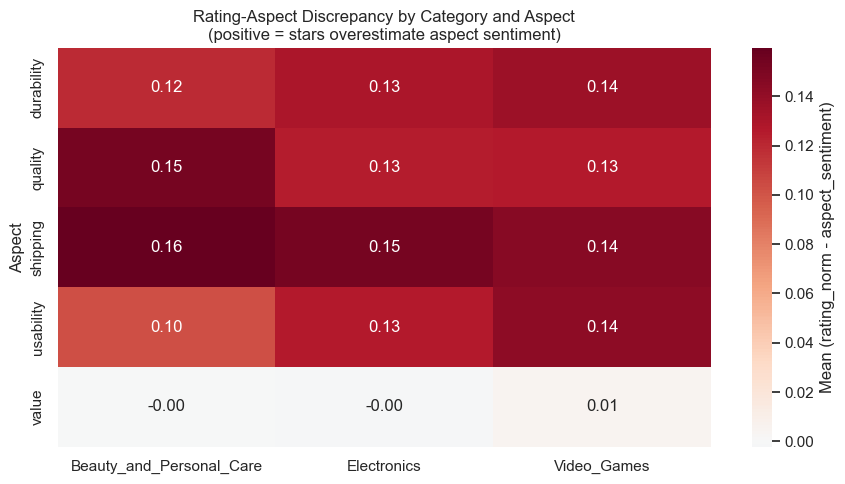

In [11]:
rad_matrix = rad.pivot(index='aspect', columns='category', values='rad')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(rad_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label': 'Mean (rating_norm - aspect_sentiment)'}, ax=ax)
ax.set_title('Rating-Aspect Discrepancy by Category and Aspect\n(positive = stars overestimate aspect sentiment)')
ax.set_xlabel('')
ax.set_ylabel('Aspect')
plt.tight_layout()
plt.savefig(os.path.join(LOCAL, 'rad_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

## Time series: HDR by year

How does hidden dissatisfaction evolve over time?

In [12]:
hdr_year = (high.groupby(['category', 'aspect', 'year'])
                .agg(n_high_rating=('review_id', 'count'),
                     n_negative=('is_negative', 'sum'))
                .reset_index())
hdr_year['hdr'] = hdr_year['n_negative'] / hdr_year['n_high_rating']
hdr_year = hdr_year[hdr_year['n_high_rating'] >= 100]

hdr_year.to_csv(os.path.join(LOCAL, 'hdr_by_year.csv'), index=False)
print(f'Saved hdr_by_year.csv ({len(hdr_year)} rows after n>=100 filter)')
hdr_year.head(10)

Saved hdr_by_year.csv (215 rows after n>=100 filter)


,category,aspect,year,n_high_rating,n_negative,hdr
6,Beauty_and_Personal_Care,durability,2011,117,10,0.085470
7,Beauty_and_Personal_Care,durability,2012,295,35,0.118644
8,Beauty_and_Personal_Care,durability,2013,991,85,0.085772
9,Beauty_and_Personal_Care,durability,2014,1125,127,0.112889
10,Beauty_and_Personal_Care,durability,2015,1166,145,0.124357
11,Beauty_and_Personal_Care,durability,2016,1490,196,0.131544
12,Beauty_and_Personal_Care,durability,2017,1420,192,0.135211
13,Beauty_and_Personal_Care,durability,2018,1556,208,0.133676
14,Beauty_and_Personal_Care,durability,2019,2046,286,0.139785
15,Beauty_and_Personal_Care,durability,2020,2953,482,0.163224


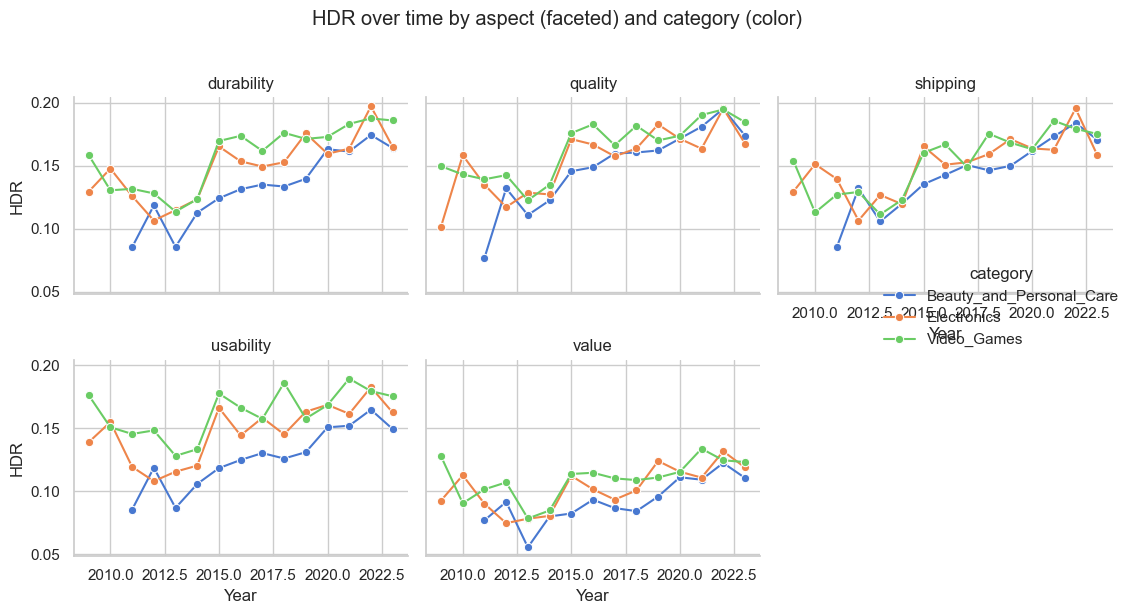

In [13]:
g = sns.FacetGrid(hdr_year, col='aspect', col_wrap=3, height=3, hue='category', sharey=True)
g.map(sns.lineplot, 'year', 'hdr', marker='o')
g.add_legend()
g.set_axis_labels('Year', 'HDR')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('HDR over time by aspect (faceted) and category (color)', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(LOCAL, 'hdr_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()

## Headline findings

**1. Stars overestimate aspect satisfaction except on value.**

RAD (rating_norm − aspect_sentiment) per category-aspect:

| Category | quality | shipping | durability | usability | **value** |
|---|---|---|---|---|---|
| Beauty | +0.15 | +0.16 | +0.12 | +0.10 | **−0.001** |
| Electronics | +0.13 | +0.15 | +0.13 | +0.13 | **−0.002** |
| Video Games | +0.13 | +0.14 | +0.14 | +0.14 | **+0.005** |

Across all three categories, star ratings systematically overestimate user satisfaction on quality, shipping, durability, and usability (gaps of +0.10 to +0.16), but align almost perfectly with sentiment on value (gap ≈ 0). One reading: when a user gives 4–5 stars, the rating mainly conveys "worth the money", not "no complaints about how it actually performs".

**2. Hidden Dissatisfaction is highest on quality, lowest on value.**

Among 4–5 star reviews, the fraction expressing negative sentiment per aspect:

| Category | quality | shipping | durability | usability | value |
|---|---|---|---|---|---|
| Beauty | **16.4%** | 15.5% | 14.5% | 13.7% | 9.9% |
| Electronics | 16.1% | 15.5% | 15.4% | 15.1% | 10.5% |
| Video Games | **16.6%** | 15.5% | 15.9% | 16.2% | 10.9% |

Roughly 1 in 6 high-rated reviews quietly complains about product quality. Value is consistently the lowest HDR (~10%), consistent with finding #1.

**3. Cross-category differences are small.**

The expected H&H 1982 prediction was that sensory (Beauty) vs. hedonic (Video Games) vs. utilitarian (Electronics) products would diverge on which aspects matter. The HDR table shows surprisingly similar profiles across categories — within 1–2 percentage points per aspect. The discrepancy is mainly *within* category (different aspects) rather than *between* categories, which is itself a finding worth flagging.

**4. Time series: HDR is rising on most aspects since ~2015.**

See the faceted line plot above. The trend is most visible on durability and shipping, where modern reviewers are increasingly willing to flag problems while still giving 4–5 stars. (Caveat: pre-2010 cells are sparse and filtered out.)

## Limitations and honest reporting

1. **ABSA model polarization.** Across every (category, aspect) cell, the label distribution is ~55% Negative / ~44% Positive / ~1% Neutral — remarkably uniform. Two plausible causes: (a) `yangheng/deberta-v3-base-absa-v1.1` rarely predicts Neutral on conversational review text, (b) when an aspect is not actually discussed, the model falls back on overall review sentiment. Either way, **absolute HDR values are likely inflated**; relative comparisons across categories and aspects remain interpretable.

2. **Stratified sample by rating.** The Stage 2 sample is balanced across the 5 rating levels (~30K each), not the natural Amazon distribution (heavily skewed toward 5 stars). This was intentional — to guarantee enough 4–5 star reviews for HDR — but it means raw counts cannot be extrapolated to population-level prevalence.

3. **Universal aspect taxonomy, not BERTopic-derived.** Stage 4's BERTopic discovered clusters that turned out to be product sub-categories (e.g., "Eye Makeup", "Gaming Headsets") rather than evaluation aspects. We therefore used a fixed 5-aspect taxonomy (quality, value, shipping, durability, usability) for ABSA, sacrificing data-driven aspect discovery for cross-category comparability. The discovered topic assignments are preserved in `processed/topics/` for future per-subcategory analysis.

4. **150K of 700K reviews sampled for ABSA.** GPU runtime budget. Per category × per aspect each have N=50K, which is statistically more than enough for HDR proportions (95% CI half-width <0.5pp).

## Push aggregated results back to S3

In [14]:
s3 = boto3.client('s3')
for fn in ['hdr_by_category_aspect.csv', 'rad_by_category_aspect.csv', 'hdr_by_year.csv']:
    local = os.path.join(LOCAL, fn)
    key = f'processed/aggregation/{fn}'
    s3.upload_file(local, BUCKET, key)
    print(f'Uploaded {fn} -> s3://{BUCKET}/{key}')

Uploaded hdr_by_category_aspect.csv -> s3://evahu-beyond-stars-raw/processed/aggregation/hdr_by_category_aspect.csv
Uploaded rad_by_category_aspect.csv -> s3://evahu-beyond-stars-raw/processed/aggregation/rad_by_category_aspect.csv
Uploaded hdr_by_year.csv -> s3://evahu-beyond-stars-raw/processed/aggregation/hdr_by_year.csv
